## how much is the data unbalanced

while my team has worked on this data before i find myself completely new to this data, and how its been used or its purpose, and thus this document is to find out how the data looks, how i must use it, what are we balancing, what is the goal to predict.

also this initial note is particular to my enviorment, as it doesnt work like the notebook of everyone else, thus for this upload i modify the paths before submitting or including the document

In [2]:
!pwd
!ls

/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope
CTGAN  GANS  c2			      data		project1
FINs   c1    classAdversarialExample  instructions.txt	tf_env


In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("../data/raw/train_clean.csv")


In [5]:
print("\n=== BASIC INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())



=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90194 entries, 0 to 90193
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       90194 non-null  float64
 1   Occupation                90194 non-null  object 
 2   Annual_Income             90194 non-null  float64
 3   Monthly_Inhand_Salary     90194 non-null  float64
 4   Num_Bank_Accounts         90194 non-null  int64  
 5   Num_Credit_Card           90194 non-null  int64  
 6   Interest_Rate             90194 non-null  float64
 7   Num_of_Loan               90194 non-null  float64
 8   Type_of_Loan              90194 non-null  object 
 9   Delay_from_due_date       90194 non-null  int64  
 10  Num_of_Delayed_Payment    90194 non-null  float64
 11  Changed_Credit_Limit      90194 non-null  float64
 12  Num_Credit_Inquiries      90194 non-null  float64
 13  Credit_Mix                90194 non-null 

In [6]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\n=== CATEGORICAL COLUMNS ===")
print(categorical_cols)

print("\n=== NUMERICAL COLUMNS ===")
print(numerical_cols)



=== CATEGORICAL COLUMNS ===
['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Credit_Score', 'Spending_Level', 'Payment_Size']

=== NUMERICAL COLUMNS ===
['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Years']


In [7]:
print("\n=== CATEGORICAL DISTRIBUTIONS ===")

imbalance_report = []

for col in categorical_cols:
    print(f"\n--- {col} ---")
    
    counts = df[col].value_counts()
    ratios = df[col].value_counts(normalize=True)
    
    print("Counts:")
    print(counts)
    
    print("\nRatios:")
    print(ratios)
    
    # Detect imbalance
    max_ratio = ratios.max()
    
    imbalance_report.append({
        "column": col,
        "max_ratio": max_ratio,
        "num_classes": len(counts)
    })



=== CATEGORICAL DISTRIBUTIONS ===

--- Occupation ---
Counts:
Occupation
Lawyer           6382
Engineer         6169
Architect        6163
Mechanic         6131
Scientist        6111
Developer        6075
Media_Manager    6066
Accountant       6036
Teacher          6031
Entrepreneur     5961
Doctor           5929
Journalist       5890
Manager          5785
Musician         5744
Writer           5721
Name: count, dtype: int64

Ratios:
Occupation
Lawyer           0.070759
Engineer         0.068397
Architect        0.068330
Mechanic         0.067976
Scientist        0.067754
Developer        0.067355
Media_Manager    0.067255
Accountant       0.066922
Teacher          0.066867
Entrepreneur     0.066091
Doctor           0.065736
Journalist       0.065304
Manager          0.064140
Musician         0.063685
Writer           0.063430
Name: proportion, dtype: float64

--- Type_of_Loan ---
Counts:
Type_of_Loan
Not_Specified                                                                       

In [8]:
print("\n=== NUMERICAL SUMMARY ===")
print(df[numerical_cols].describe())



=== NUMERICAL SUMMARY ===
                Age  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  \
count  90194.000000   90194.000000           90194.000000       90194.000000   
mean      33.221899   48113.049005            3998.589062           5.423476   
std       10.744523   34849.811546            2899.309366           2.580755   
min       14.000000    7005.930000             303.645417           0.000000   
25%       24.000000   19184.247500            1615.457500           4.000000   
50%       33.000000   36298.360000            3032.155000           6.000000   
75%       41.000000   69601.240000            5782.894507           7.000000   
max       56.000000  149168.880000           12696.463333          11.000000   

       Num_Credit_Card  Interest_Rate   Num_of_Loan  Delay_from_due_date  \
count     90194.000000   90194.000000  90194.000000         90194.000000   
mean          5.557254      14.685445      3.567266            21.332694   
std           2.067258  

In [9]:
imbalance_df = pd.DataFrame(imbalance_report)

print("\n=== IMBALANCE DETECTION ===")

# threshold: if one class >70%, it's imbalanced
imbalanced_cols = imbalance_df[imbalance_df["max_ratio"] > 0.7]

print(imbalanced_cols.sort_values(by="max_ratio", ascending=False))




=== IMBALANCE DETECTION ===
Empty DataFrame
Columns: [column, max_ratio, num_classes]
Index: []


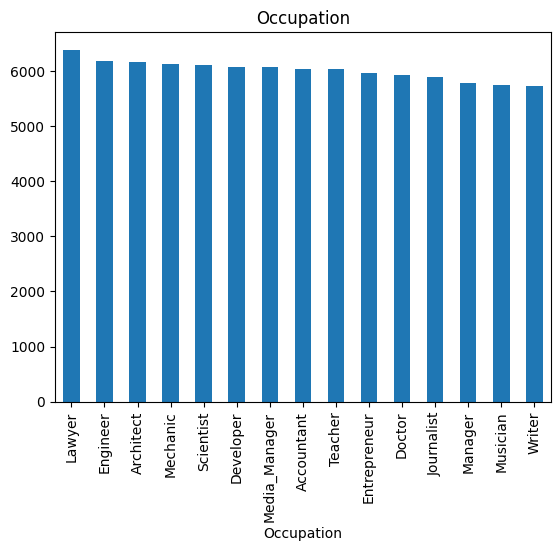

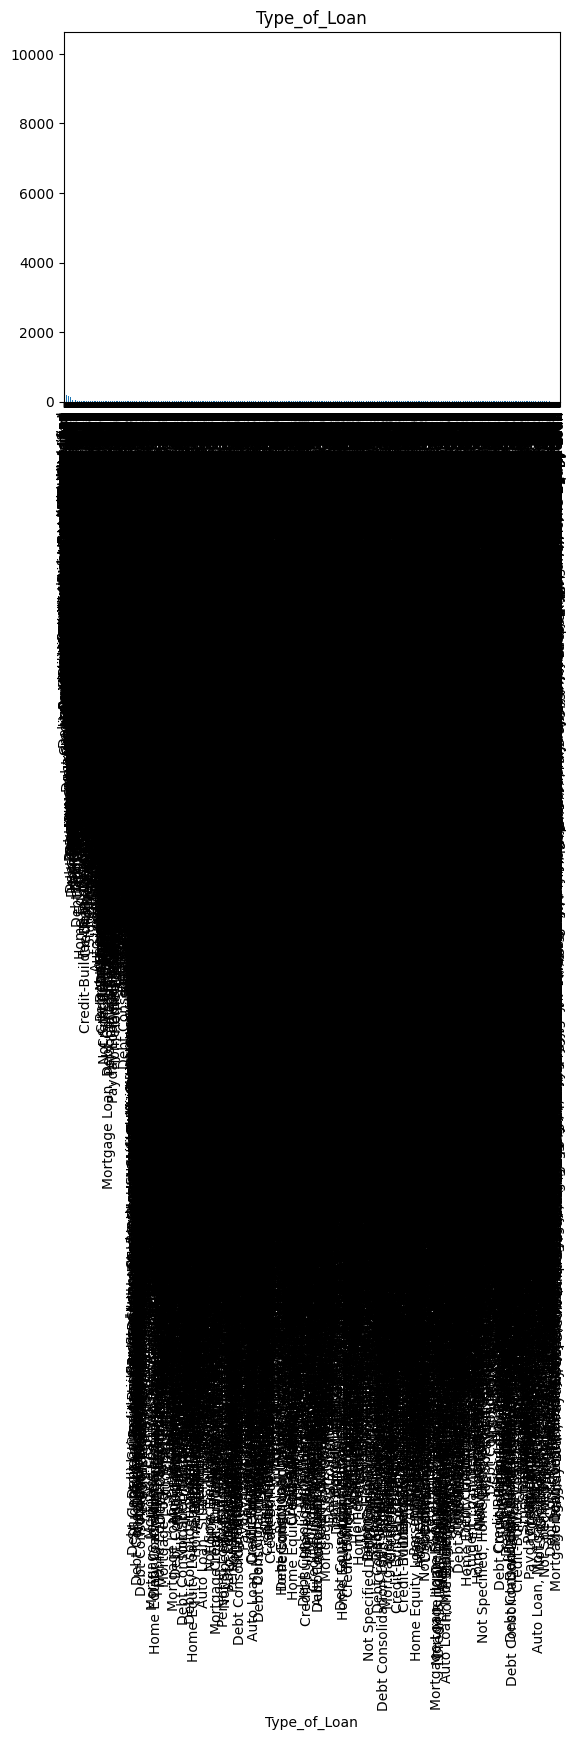

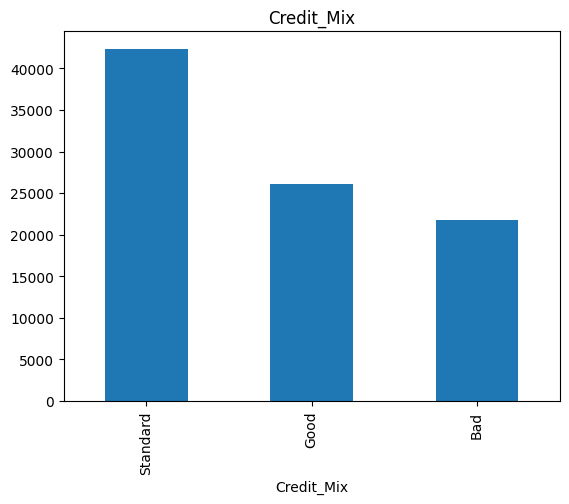

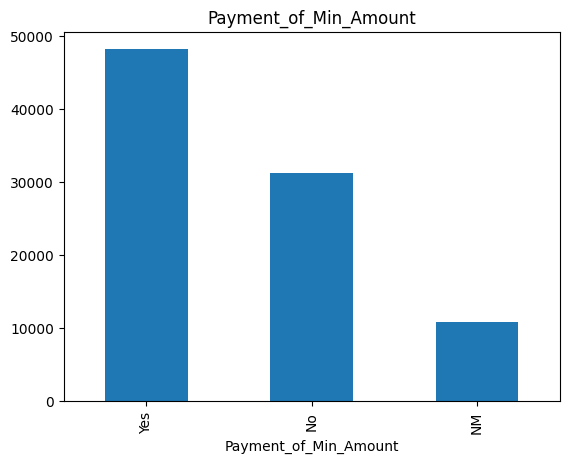

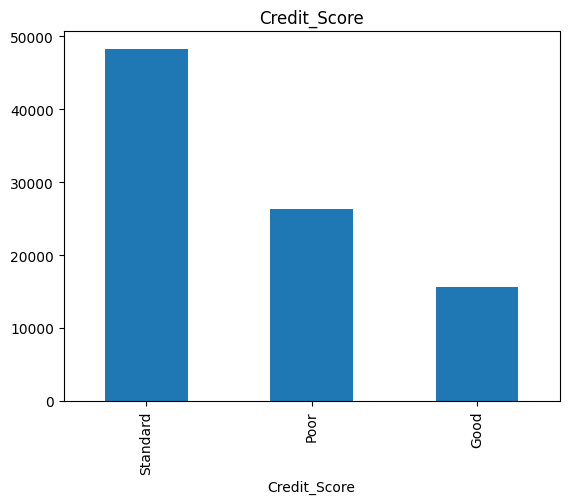

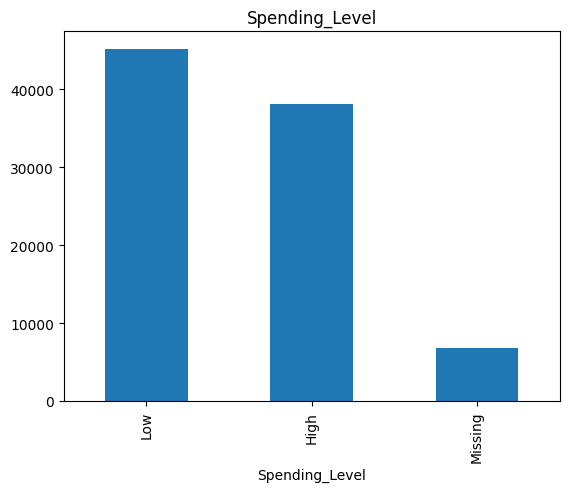

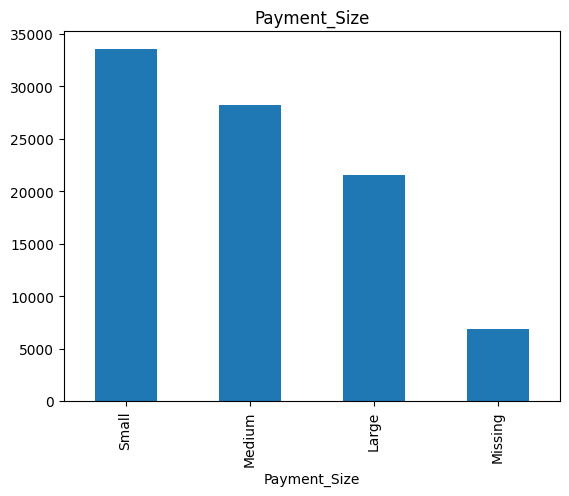

In [10]:
import matplotlib.pyplot as plt

for col in categorical_cols:
    df[col].value_counts().plot(kind='bar', title=col)
    plt.show()